# Πρόβλεψη του Όγκου Επισκέψεων στο Τμήμα Επειγόντων Περιστατικών με Εκθετική Εξομάλυνση (PROC ESM)

## Σύνοψη

Ένα νοσοκομειακό σύστημα μεσαίου μεγέθους χρειάζεται μια πρόβλεψη ενός έτους για τον μηνιαίο όγκο επισκέψεων στο τμήμα επειγόντων περιστατικών (ΤΕΠ), ώστε να σχεδιάσει τη στελέχωση νοσηλευτών και τη δυναμικότητα κλινών πριν από τη χειμερινή έξαρση των αναπνευστικών λοιμώξεων. Αυτό το σημειωματάριο κατασκευάζει μια συνθετική τετραετή μηνιαία απογραφή του ΤΕΠ (48 μήνες, Ιαν 2021 - Δεκ 2024) και προσαρμόζει ένα πολλαπλασιαστικό εποχιακό μοντέλο Winters με το **PROC ESM** για να παραγάγει μια πρόβλεψη 12 μηνών με διαστήματα πρόβλεψης 95%.

Το προσαρμοσμένο μοντέλο αποτυπώνει καλά τη σειρά: εντός δείγματος το **RMSE είναι περίπου 320 επισκέψεις** και το **MAPE είναι 4.16%**, οπότε το τυπικό μηνιαίο σφάλμα είναι κάτω από το 5% του όγκου. Η πρόβλεψη προεκτείνει το γνώριμο εποχιακό σχήμα στο 2025 - μια κορυφή Δεκεμβρίου-Φεβρουαρίου κοντά στις **7,300-7,800 επισκέψεις/μήνα** και μια κοιλάδα στα τέλη του καλοκαιριού κοντά στις **5,800-5,900** - με ζώνες πρόβλεψης που διευρύνονται καθώς επεκτείνεται ο ορίζοντας. Αυτοί οι αριθμοί, και τα βάρη εξομάλυνσης πίσω από αυτούς, διαβάζονται απευθείας από τα σύνολα δεδομένων εξόδου της διαδικασίας παρακάτω.

## Πηγές Δεδομένων

| Σύνολο δεδομένων | Γραμμές | Επίπεδο ανάλυσης | Βασικές μεταβλητές | Περιγραφή |
|---------|------|-------|---------------|-------------|
| `ed_census` | 48 | Μία γραμμή ανά ημερολογιακό μήνα, Ιαν 2021 - Δεκ 2024 | `month` (μηνιαία ημερομηνία SAS), `ed_visits` (ακέραιος αριθμός μηνιαίων επισκέψεων στο ΤΕΠ) | Συνθετικός μηνιαίος όγκος επισκέψεων στο τμήμα επειγόντων περιστατικών για ένα νοσοκομειακό σύστημα μεσαίου μεγέθους. Παράγεται με ανοδική τάση ανάπτυξης (~3% ετησίως), έναν πολλαπλασιαστικό εποχιακό κύκλο που κορυφώνεται στη χειμερινή περίοδο των αναπνευστικών λοιμώξεων (Δεκ-Φεβ) και υποχωρεί στα τέλη του καλοκαιριού, συν λογαριθμοκανονικό θόρυβο ώστε το εποχιακό πλάτος να κλιμακώνεται με το αυξανόμενο επίπεδο. |

# Πρόβλεψη του Όγκου Επισκέψεων στο Τμήμα Επειγόντων Περιστατικών με PROC ESM

Οι υπεύθυνοι σχεδιασμού δυναμικότητας χρειάζεται να γνωρίζουν πόσες επισκέψεις στο ΤΕΠ να αναμένουν κάθε μήνα, ώστε να προγραμματίζουν νοσηλευτές, να κρατούν ευέλικτες κλίνες και να προετοιμάζουν αναπνευστικό υλικό πριν από τη χειμερινή έξαρση. Ο όγκος του ΤΕΠ είναι μια κλασική εποχιακή χρονοσειρά: αυξάνεται αργά από έτος σε έτος, κορυφώνεται κατά τη διάρκεια της αναπνευστικής περιόδου Δεκεμβρίου-Φεβρουαρίου και υποχωρεί στα τέλη του καλοκαιριού, ενώ το μέγεθος της εποχιακής διακύμανσης αυξάνεται καθώς αυξάνεται ο βασικός όγκος. Αυτή ακριβώς η πολλαπλασιαστική εποχιακή δομή είναι που η πολλαπλασιαστική μέθοδος Winters στο **PROC ESM** είναι σχεδιασμένη να αποτυπώνει.

Σε αυτό το σημειωματάριο:

1. Παράγουμε μια ρεαλιστική τετραετή μηνιαία απογραφή του ΤΕΠ με τάση, πολλαπλασιαστική εποχικότητα και θόρυβο.
2. Οπτικοποιούμε τη σειρά για να επιβεβαιώσουμε την πολλαπλασιαστική εποχιακή δομή της.
3. Προσαρμόζουμε ένα πολλαπλασιαστικό μοντέλο Winters με το PROC ESM και διαβάζουμε τα βάρη εξομάλυνσης και τα στατιστικά προσαρμογής του από τα σύνολα δεδομένων εξόδου.
4. Παράγουμε μια πρόβλεψη 12 μηνών μπροστά με διαστήματα πρόβλεψης 95% και ερμηνεύουμε τις επιχειρησιακές επιπτώσεις.

## Βήμα 1 - Παραγωγή της συνθετικής μηνιαίας απογραφής του ΤΕΠ

Κατασκευάζουμε 48 μηνιαίες παρατηρήσεις από τον Ιανουάριο του 2021 έως τον Δεκέμβριο του 2024. Ο αναμενόμενος όγκος κάθε μήνα είναι ένα βασικό επίπεδο που αυξάνεται περίπου 3% ετησίως, πολλαπλασιασμένο με έναν εποχιακό δείκτη (υψηλότερος στα μέσα του χειμώνα, χαμηλότερος στα τέλη του καλοκαιριού), και στη συνέχεια διαταράσσεται από λογαριθμοκανονικό θόρυβο ώστε η τυχαία διακύμανση να κλιμακώνεται με το επίπεδο. Η `intnx` προωθεί την ευθυγραμμισμένη σε μήνα ημερομηνία κατά μία περίοδο ανά γραμμή, και η `streaminit` καθιστά την κλήρωση αναπαραγώγιμη.

In [1]:
ΔΕΔΟΜΕΝΑ ed_census;
    CALL streaminit(20240531);
    /* Monthly seasonal index: peaks Dec-Feb (flu/RSV), troughs Aug-Sep */
    ARRAY seas{12} _temporary_
        (1.18 1.14 1.05 0.97 0.93 0.90 0.92 0.86 0.88 0.97 1.06 1.14);
    ΜΟΡΦΗ month yymmn6.;
    ΕΠΑΝΑΛΗΨΗ i = 1 ΕΩΣ 48;
        month = intnx('month', '01JAN2021'd, i - 1);
        m = month(month);
        /* Baseline ~6000 visits/mo growing ~3% per year */
        level = 6000 * (1.03 ** ((i - 1) / 12));
        /* Multiplicative seasonality + level-scaled lognormal noise */
        noise = EXP(rand('normal', 0, 0.035));
        ed_visits = round(level * seas{m} * noise);
        ΕΞΟΔΟΣ;
    ΤΕΛΟΣ;
    ΚΡΑΤΗΣΗ month ed_visits;
ΕΚΤΕΛΕΣΗ;

ΔΙΑΔΙΚΑΣΙΑ ΕΚΤΥΠΩΣΗ ΔΕΔΟΜΕΝΑ=ed_census(obs=14) noobs ΕΤΙΚΕΤΑ;
    ΕΤΙΚΕΤΑ month = 'Μήνας' ed_visits = 'Επισκέψεις ΤΕΠ';
    TITLE 'Πρώτοι 14 μήνες συνθετικού όγκου επισκέψεων ΤΕΠ';
ΕΚΤΕΛΕΣΗ;


                                    Πρώτοι 14 μήνες συνθετικού όγκου επισκέψεων ΤΕΠ                                     

     Μήνας               Επισκέψεις ΤΕΠ
    202101                         7103
    202102                         6835
    202103                         6668
    202104                         5611
    202105                         5816
    202106                         5383
    202107                         5586
    202108                         5283
    202109                         5161
    202110                         6109
    202111                         6451
    202112                         6730
    202201                         6847
    202202                         7213

... 34 more observations (showing 14 of 48)




NOTE: DATA ed_census


NOTE: Wrote ed_census (48 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=ed_census

NOTE: PROC PRINT completed: 14 observations printed, 2 variables


Οι πρώτοι μήνες επιβεβαιώνουν τον σχεδιασμό: ο όγκος ξεκινά κοντά στις 7,100 στην κορυφή του Ιανουαρίου 2021, πέφτει μέσα στην άνοιξη και το καλοκαίρι έως την κοιλάδα Αυγούστου-Σεπτεμβρίου, και έπειτα ανεβαίνει ξανά προς τον επόμενο χειμώνα. Μέχρι τον Ιανουάριο του 2022 η κορυφή έχει ανέβει ελαφρώς σε περίπου 6,800-7,200, αντικατοπτρίζοντας την ετήσια ανάπτυξη ~3% που προστίθεται στον εποχιακό κύκλο.

## Βήμα 2 - Οπτικοποίηση της σειράς

Πριν από τη μοντελοποίηση, σχεδιάζουμε την ακατέργαστη σειρά για να επιβεβαιώσουμε τη δομή που αναμένουμε: μια ήπια ανοδική τάση με μια επαναλαμβανόμενη ετήσια κορυφή κάθε χειμώνα, της οποίας το πλάτος διευρύνεται με τον χρόνο. Μια διευρυνόμενη εποχιακή διακύμανση είναι το χαρακτηριστικό γνώρισμα μιας *πολλαπλασιαστικής* εποχιακής διαδικασίας και μας υποδεικνύει ποιο μοντέλο ESM να επιλέξουμε.

                                    Πρώτοι 14 μήνες συνθετικού όγκου επισκέψεων ΤΕΠ                                     




NOTE: PROC SGPLOT data=ed_census

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


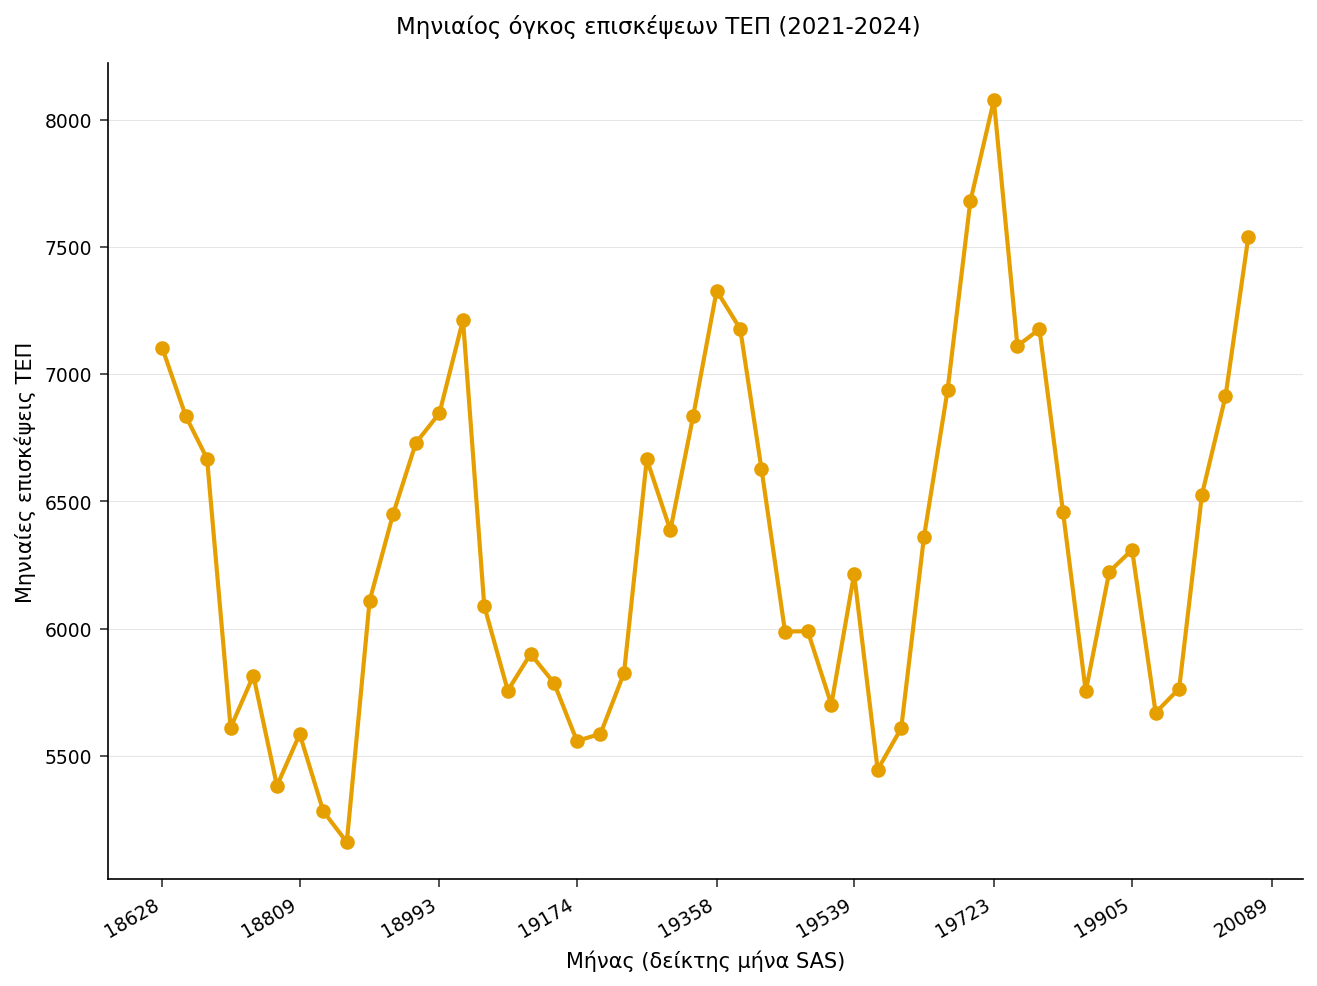

In [2]:
ΔΙΑΔΙΚΑΣΙΑ SGPLOT ΔΕΔΟΜΕΝΑ=ed_census;
    SERIES x=month y=ed_visits / MARKERS
        MARKERATTRS=(SYMBOL=circlefilled)
        LINEATTRS=(thickness=2);
    XAXIS ΕΤΙΚΕΤΑ='Μήνας (δείκτης μήνα SAS)';
    YAXIS ΕΤΙΚΕΤΑ='Μηνιαίες επισκέψεις ΤΕΠ' grid;
    TITLE 'Μηνιαίος όγκος επισκέψεων ΤΕΠ (2021-2024)';
ΕΚΤΕΛΕΣΗ;


Το γράφημα δείχνει τέσσερις καθαρούς ετήσιους κύκλους. Κάθε χειμερινή κορυφή βρίσκεται λίγο ψηλότερα από την προηγούμενη, ανεβαίνοντας από περίπου 7,100 το 2021 σε περίπου 8,100 στην κορυφή του 2024, ενώ οι καλοκαιρινές κοιλάδες ανεβαίνουν πιο μετριοπαθώς - η εποχιακή διακύμανση αυξάνεται με το επίπεδο. Αυτό το διευρυνόμενο πλάτος είναι το σήμα κατατεθέν της πολλαπλασιαστικής εποχικότητας και δικαιολογεί το `MODEL=WINTERS` (πολλαπλασιαστικό Winters) στο επόμενο βήμα.

## Βήμα 3 - Προσαρμογή του πολλαπλασιαστικού μοντέλου Winters

Προσαρμόζουμε πολλαπλασιαστική εποχιακή εξομάλυνση Winters στο πλήρες ιστορικό των 48 μηνών. Η δήλωση `ID` ορίζει το `month` ως τον χρονικό δείκτη σε διάστημα `MONTH`, και η δήλωση `FORECAST` ζητά `MODEL=WINTERS` με `LEAD=12` για προβολή ενός έτους μπροστά. Καταγράφουμε τρία σύνολα δεδομένων εξόδου:

- `OUT=` - η ιστορική σειρά με προσαρτημένη την πρόβλεψη (μία στήλη `ed_visits`), με τον χρονικό δείκτη επεκτεταμένο στον ορίζοντα πρόβλεψης - ιδανικό για σχεδίαση.
- `OUTFOR=` - τα συστατικά πρόβλεψης ανά περίοδο: σημειακή πρόβλεψη (`PREDICT`) και τα κατώτερα/ανώτερα όρια πρόβλεψης.
- `OUTSUM=` - τα στατιστικά προσαρμογής του μοντέλου (RMSE, MAE, MAPE, AIC) και τα βάρη εξομάλυνσης, σε μία μόνο γραμμή σύνοψης.

Το `ALPHA=0.05` αποδίδει όρια πρόβλεψης 95%, κατάλληλα για τα περιθώρια κινδύνου του σχεδιασμού δυναμικότητας. Το `PRINT=(STATISTICS)` εμφανίζει τα στατιστικά προσαρμογής και τα βάρη εξομάλυνσης στο listing.

In [3]:
ΔΙΑΔΙΚΑΣΙΑ esm ΔΕΔΟΜΕΝΑ=ed_census
        LEAD=12
        out=ed_with_forecast
        outfor=esm_forecast
        outsum=esm_summary
        ΕΚΤΥΠΩΣΗ=(statistics);
    id month interval=month;
    forecast ed_visits / ΜΟΝΤΕΛΟ=winters ALPHA=0.05;
ΕΚΤΕΛΕΣΗ;

ΔΙΑΔΙΚΑΣΙΑ ΕΚΤΥΠΩΣΗ ΔΕΔΟΜΕΝΑ=esm_summary noobs ΕΤΙΚΕΤΑ;
    ΕΤΙΚΕΤΑ rmse='RMSE' mae='MAE' mape='MAPE'
          ALPHA='Επίπεδο (άλφα)' beta='Τάση (βήτα)' gamma='Εποχικότητα (γάμμα)';
    ΜΕΤΑΒΛΗΤΗ rmse mae mape ALPHA beta gamma;
    TITLE 'Στατιστικά προσαρμογής Winters και βάρη εξομάλυνσης';
ΕΚΤΕΛΕΣΗ;


                                    Πρώτοι 14 μήνες συνθετικού όγκου επισκέψεων ΤΕΠ                                     


Exponential Smoothing Forecast for ed_visits
Method: WINTERS
Number of Observations: 48
Forecast Periods: 12

Fit Statistics:
  RMSE     = 320.4349
  MAE      = 264.4440
  MAPE     = 4.1597
  MSE      = 102678.4971
  AIC      = 421.4169

Smoothing Weights:
  ALPHA      = 0.3000
  BETA       = 0.1000
  GAMMA      = 0.1000

Forecasts:
  Period     Predict        
  1          7822.1805      
  2          7538.7511      
  3          7291.7885      
  4          6262.7158      
  5          6396.7222      
  6          6039.1562      
  7          6235.5688      
  8          5867.3108      
  9          5801.6677      
  10         6803.9608      
  11         7172.6105      
  12         7566.8263      



                                  Στατιστικά προσαρμογής Winters και βάρη εξομάλυνσης                                   

          RMSE            MAE         MA


NOTE: PROC ESM data=ed_census

NOTE: Using Python for ESM estimation
NOTE: Output dataset ED_WITH_FORECAST created with 60 observations.
NOTE: Output dataset ESM_FORECAST created with 60 observations.
NOTE: PROC PRINT data=esm_summary

NOTE: PROC PRINT completed: 1 observations printed, 6 variables


Η γραμμή `OUTSUM=` και τα εκτυπωμένα στατιστικά συμφωνούν: η πολλαπλασιαστική προσαρμογή Winters επιτυγχάνει εντός δείγματος **RMSE 320.4 επισκέψεων**, **MAE 264.4** και **MAPE 4.16%** - ένα τυπικό μηνιαίο σφάλμα αρκετά κάτω από το 5% του όγκου, που είναι άνετα ακριβές για τον σχεδιασμό στελέχωσης. Τα βάρη εξομάλυνσης είναι **alpha = 0.30** (επίπεδο), **beta = 0.10** (τάση) και **gamma = 0.10** (εποχή). Το μέτριο βάρος επιπέδου επιτρέπει στη βάση να μετατοπίζεται προς τα πάνω με την αύξηση του πληθυσμού των ασθενών, ενώ τα μικρά βάρη τάσης και εποχής αντικατοπτρίζουν ότι ο ρυθμός ανάπτυξης και το σχήμα της χειμερινής έξαρσης είναι σταθερά από έτος σε έτος και δεν πρέπει να προκαλούν υπερβολική αντίδραση από μήνα σε μήνα.

> Σημείωση: πρόκειται για στατιστικά προσαρμογής *εντός δείγματος* που υπολογίζονται στο δείγμα εκτίμησης, όχι για ένα εκτός δείγματος σύνολο ελέγχου. Ποσοτικοποιούν πόσο στενά παρακολουθεί το μοντέλο το ιστορικό στο οποίο προσαρμόστηκε.

## Βήμα 4 - Συγκρότηση και πινακοποίηση της πρόβλεψης 12 μηνών

Το σύνολο δεδομένων `OUTFOR=` περιέχει τη σημειακή πρόβλεψη και τα όρια πρόβλεψης για κάθε περίοδο, ενώ το σύνολο δεδομένων `OUT=` φέρει τον χρονικό δείκτη επεκτεταμένο καθαρά στον ορίζοντα πρόβλεψης. Ευθυγραμμίζουμε τα δύο κατά σειρά παρατήρησης για να συνδέσουμε τις ημερομηνίες πρόβλεψης με τα όρια πρόβλεψης, και έπειτα κρατάμε μόνο τους 12 μήνες πρόβλεψης. Αυτοί είναι οι αριθμοί βάσει των οποίων θα ενεργούσε μια επιτροπή στελέχωσης.

In [4]:
/* OUT= carries the forecast-horizon dates; OUTFOR= carries the
   prediction limits. Align them by observation order to put dates on
   the limits, then keep only the 12 forecast months.            */
ΔΕΔΟΜΕΝΑ out_idx;
    ΟΡΙΣΜΟΣ ed_with_forecast;
    row = _n_;
    RENAME month = fdate ed_visits = series_value;
ΕΚΤΕΛΕΣΗ;

ΔΕΔΟΜΕΝΑ for_idx;
    ΟΡΙΣΜΟΣ esm_forecast;
    row = _n_;
    RENAME ed_visits = observed;
    ΚΡΑΤΗΣΗ row observed predict LOWER UPPER;
ΕΚΤΕΛΕΣΗ;

ΔΕΔΟΜΕΝΑ forecast_path;
    ΣΥΓΧΩΝΕΥΣΗ out_idx for_idx;
    ΚΑΤΑ row;
    ΜΟΡΦΗ fdate yymmn6. series_value observed predict LOWER UPPER comma8.0;
ΕΚΤΕΛΕΣΗ;

ΔΕΔΟΜΕΝΑ forecast_horizon;
    ΟΡΙΣΜΟΣ forecast_path;
    ΟΠΟΥ observed = .;   /* forecast months only (no observed value) */
    ΚΡΑΤΗΣΗ fdate predict LOWER UPPER;
ΕΚΤΕΛΕΣΗ;

ΔΙΑΔΙΚΑΣΙΑ ΕΚΤΥΠΩΣΗ ΔΕΔΟΜΕΝΑ=forecast_horizon noobs ΕΤΙΚΕΤΑ;
    ΕΤΙΚΕΤΑ fdate   = 'Μήνας'
          predict = 'Προβλεπόμενες επισκέψεις'
          LOWER   = '95% Κάτω όριο'
          UPPER   = '95% Άνω όριο';
    TITLE 'Πρόβλεψη επισκέψεων ΤΕΠ 12 μηνών με 95% όρια πρόβλεψης';
ΕΚΤΕΛΕΣΗ;


                                 Πρόβλεψη επισκέψεων ΤΕΠ 12 μηνών με 95% όρια πρόβλεψης                                 

     Μήνας                         Προβλεπόμενες επισκέψεις          95% Κάτω όριο         95% Άνω όριο
    202501                                            7,822                  7,194                8,450
    202502                                            7,539                  6,651                8,427
    202503                                            7,292                  6,204                8,380
    202504                                            6,263                  5,007                7,519
    202505                                            6,397                  4,992                7,801
    202506                                            6,039                  4,501                7,578
    202507                                            6,236                  4,574                7,897
    202508                                    


NOTE: DATA out_idx


NOTE: Read 60 rows from ed_with_forecast.
NOTE: Wrote out_idx (60 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA for_idx


NOTE: Read 60 rows from esm_forecast.
NOTE: Wrote for_idx (60 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA forecast_path

NOTE: Stream 1 processed 60 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 2 processed 60 rows, max BY-group size: 1 (O(1) memory verified)

NOTE: Wrote forecast_path (60 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA forecast_horizon


NOTE: Read 60 rows from forecast_path.
NOTE: Wrote forecast_horizon (12 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=forecast_horizon

NOTE: PROC PRINT completed: 12 observations printed, 4 variables


Η πρόβλεψη μεταφέρει το εποχιακό αποτύπωμα μπροστά στο 2025. Το μοντέλο προβλέπει την κορυφή του Ιανουαρίου 2025 σε περίπου **7,822 επισκέψεις** (διάστημα 95% 7,194-8,450), υποχωρεί μέσα στην άνοιξη, αγγίζει το κατώτατο σημείο στην κοιλάδα των τελών του καλοκαιριού κοντά στις **5,802** τον Σεπτέμβριο (διάστημα 3,918-7,686), και έπειτα ανασυγκροτείται σε μια κορυφή Δεκεμβρίου περίπου **7,567** (διάστημα 5,391-9,742). Η ζώνη πρόβλεψης διευρύνεται σταθερά με τον ορίζοντα - το διάστημα του επόμενου μήνα εκτείνεται περίπου +/-630 επισκέψεις, ενώ του επόμενου Δεκεμβρίου εκτείνεται περισσότερο από +/-2,000 - μια άμεση υπενθύμιση ότι τα βραχυπρόθεσμα σχέδια είναι πολύ πιο σταθερά από εκείνα του τέλους του έτους.

## Βήμα 5 - Σχεδίαση ιστορικού συν πρόβλεψης

Τέλος, επικαλύπτουμε την πρόβλεψη πάνω στο παρατηρούμενο ιστορικό ώστε οι υπεύθυνοι σχεδιασμού να μπορούν να δουν την προβλεπόμενη χειμερινή κορυφή και τη διευρυνόμενη ζώνη αβεβαιότητας καθώς επεκτείνεται ο ορίζοντας. Διαχωρίζουμε την ευθυγραμμισμένη σειρά `forecast_path` στο **παρατηρούμενο** ιστορικό (συνεχής γραμμή) και στην **πρόβλεψη 12 μηνών** (διακεκομμένη) ώστε η μετάβαση να είναι σαφής, και σχεδιάζουμε τη ζώνη πρόβλεψης 95% από κάτω. Ο άξονας x είναι ο μηνιαίος δείκτης ημερομηνίας SAS, που εκτείνεται από αριστερά προς τα δεξιά από τον Ιαν 2021 έως τον Δεκ 2025.

                                 Πρόβλεψη επισκέψεων ΤΕΠ 12 μηνών με 95% όρια πρόβλεψης                                 




NOTE: DATA forecast_plot


NOTE: Read 60 rows from forecast_path.
NOTE: Wrote forecast_plot (60 rows, 8 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SGPLOT data=forecast_plot

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


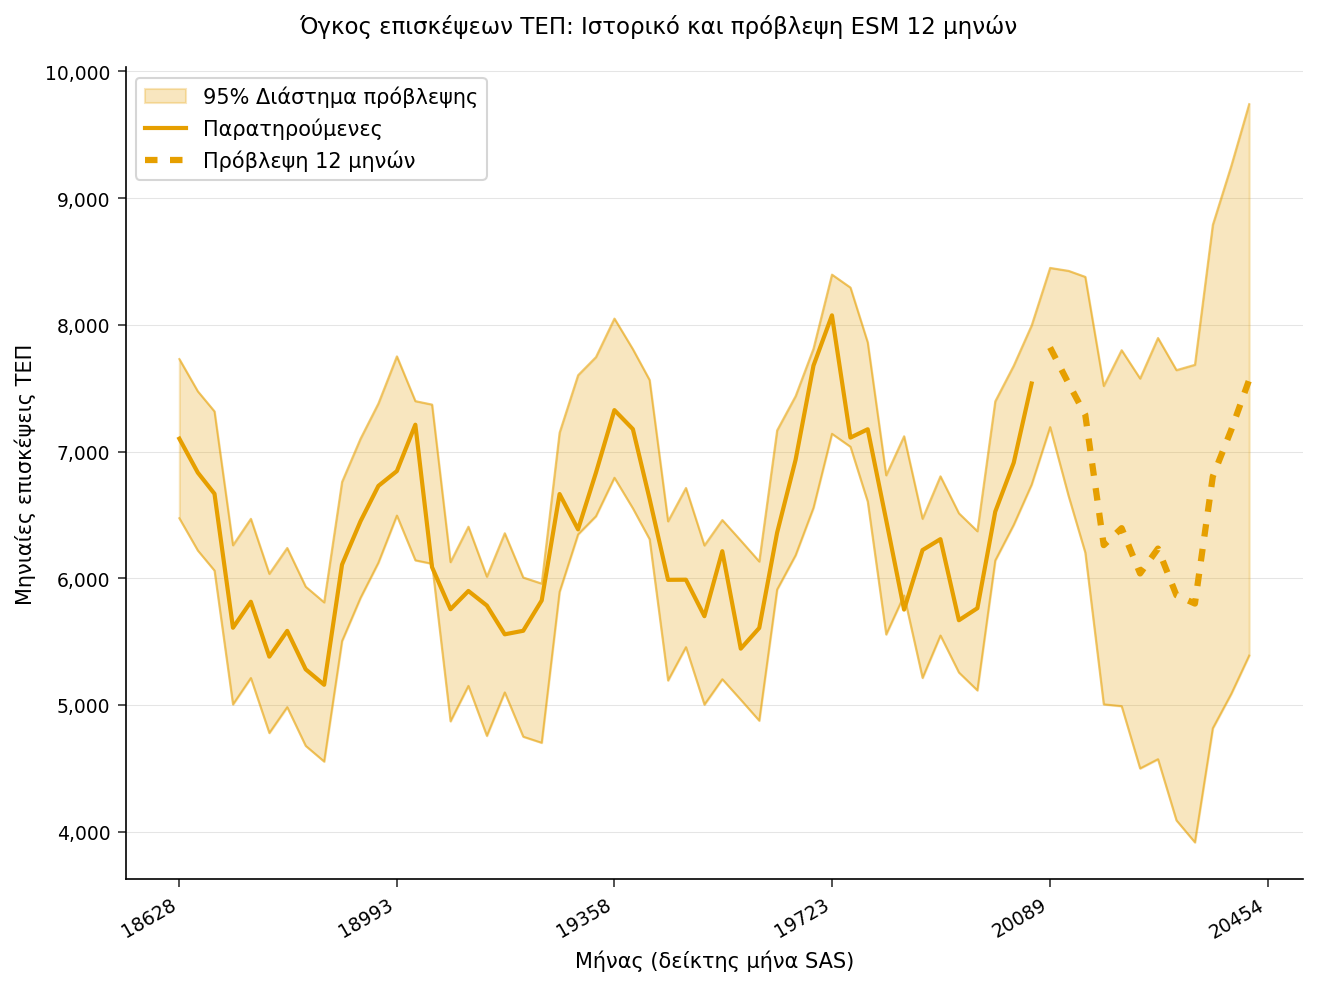

In [5]:
/* Split the projected series into the observed history and the
   12-month forecast so they render with distinct styling, and overlay
   the 95% prediction band from the aligned forecast_path dataset.   */
ΔΕΔΟΜΕΝΑ forecast_plot;
    ΟΡΙΣΜΟΣ forecast_path;
    ΕΑΝ observed = . ΤΟΤΕ fc_only = predict;   /* future months only */
    ΑΛΛΙΩΣ fc_only = .;
ΕΚΤΕΛΕΣΗ;

ΔΙΑΔΙΚΑΣΙΑ SGPLOT ΔΕΔΟΜΕΝΑ=forecast_plot;
    BAND x=fdate LOWER=LOWER UPPER=UPPER /
        legendlabel='95% Διάστημα πρόβλεψης' TRANSPARENCY=0.5;
    SERIES x=fdate y=observed / LINEATTRS=(thickness=2)
        legendlabel='Παρατηρούμενες';
    SERIES x=fdate y=fc_only / LINEATTRS=(thickness=3 pattern=shortdash)
        legendlabel='Πρόβλεψη 12 μηνών';
    XAXIS ΕΤΙΚΕΤΑ='Μήνας (δείκτης μήνα SAS)';
    YAXIS ΕΤΙΚΕΤΑ='Μηνιαίες επισκέψεις ΤΕΠ' grid;
    TITLE 'Όγκος επισκέψεων ΤΕΠ: Ιστορικό και πρόβλεψη ESM 12 μηνών';
ΕΚΤΕΛΕΣΗ;


## Ερμηνεία των αποτελεσμάτων

Το πολλαπλασιαστικό μοντέλο Winters αποσυνθέτει τον όγκο του ΤΕΠ σε ένα αργά αυξανόμενο **επίπεδο**, μια σχεδόν επίπεδη **τάση** και ένα σταθερό **εποχιακό** μοτίβο. Τα βάρη εξομάλυνσης που διαβάζονται από το `OUTSUM=` λένε την ιστορία: ένα μέτριο βάρος επιπέδου (alpha = 0.30) επιτρέπει στη βάση να μετατοπίζεται προς τα πάνω με την αύξηση του πληθυσμού των ασθενών, ενώ τα μικρά βάρη τάσης και εποχής (beta = gamma = 0.10) αντικατοπτρίζουν ότι ο ρυθμός ανάπτυξης και το σχήμα της χειμερινής έξαρσης είναι ιδιαίτερα σταθερά από έτος σε έτος και δεν πρέπει να προκαλούν υπερβολική αντίδραση από μήνα σε μήνα.

Τα **στατιστικά προσαρμογής** επιβεβαιώνουν ότι το μοντέλο παρακολουθεί καλά το ιστορικό: ένα RMSE περίπου 320 επισκέψεων και ένα MAPE 4.16% σημαίνουν ότι το τυπικό μηνιαίο σφάλμα είναι κάτω από το 5% του όγκου. Επιχειρησιακά, ο **πίνακας πρόβλεψης και το γράφημα ζώνης** ποσοτικοποιούν την κορυφή Δεκεμβρίου-Φεβρουαρίου προς την οποία θα πρέπει να στελεχωθεί το ΤΕΠ - περίπου 7,300-7,800 επισκέψεις στους χειμερινούς μήνες - και τα όρια πρόβλεψης 95% ορίζουν ένα συνετό εύρος δυναμικότητας: σχεδιάστε τη βασική στελέχωση με βάση τη σημειακή πρόβλεψη και προετοιμάστε εκ των προτέρων ευέλικτη κάλυψη και κλίνες έκτακτης ανάγκης προς το ανώτερο όριο. Το διάστημα διευρύνεται με τον ορίζοντα, οπότε το σχέδιο του επόμενου μήνα είναι πολύ πιο σταθερό από εκείνο του επόμενου Δεκεμβρίου και θα πρέπει να ανανεώνεται καθώς φτάνουν νέα πραγματικά δεδομένα.

**Επεκτάσεις:** συγκρίνετε το `MODEL=ADDWINTERS` (αθροιστική εποχικότητα) με την πολλαπλασιαστική προσαρμογή για να επιβεβαιώσετε την πολλαπλασιαστική επιλογή· εφαρμόστε `TRANSFORM=LOG` για να επιβάλετε θετικότητα και να σταθεροποιήσετε τη διακύμανση· ή προσθέστε μια δήλωση `BY` για να προβλέψετε πολλαπλές νοσοκομειακές μονάδες σε μία μόνο κλήση PROC ESM.